# 2. Explorativ dataanalys (EDA)

**Frågeställning:** Vilka kundtyper finns i vår kundbas och hur når vi dem bäst?

I den här notebooken utforskar vi datan för att förstå vilka variabler som bäst beskriver skillnader mellan kunder. Insikterna används sedan för att välja rätt variabler till klustring.

---
## 2.1 Ladda in data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Data/clean_customer_data.csv')
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,4,7,0,0,0,0,0,0,1,69
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,2,5,0,0,0,0,0,0,0,72
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,10,4,0,0,0,0,0,0,0,61
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,4,6,0,0,0,0,0,0,0,42
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,6,5,0,0,0,0,0,0,0,45


---
## 2.2 Statistisk sammanfattning

In [2]:
# Övergripande statistik för alla numeriska kolumner
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000,2205.000000
mean,1968.904308,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,...,5.823583,5.336961,0.073923,0.074376,0.073016,0.064399,0.013605,0.009070,0.15102,57.095692
std,11.705801,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,...,3.241796,2.413535,0.261705,0.262442,0.260222,0.245518,0.115872,0.094827,0.35815,11.705801
min,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,30.000000
25%,1959.000000,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,...,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,49.000000
50%,1970.000000,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,...,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,56.000000
75%,1977.000000,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,...,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,67.000000
max,1996.000000,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,...,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,86.000000


In [3]:
# Fördelning av utbildningsnivå
print(df['Education'].value_counts())

Education
Graduation    1113
PhD            476
Master         364
2n Cycle       198
Basic           54
Name: count, dtype: int64


In [4]:
# Fördelning av civilstånd
print(df['Marital_Status'].value_counts())

Marital_Status
Married     854
Together    568
Single      477
Divorced    230
Widow        76
Name: count, dtype: int64


---
## 2.3 Fördelningar av nyckelvariabler

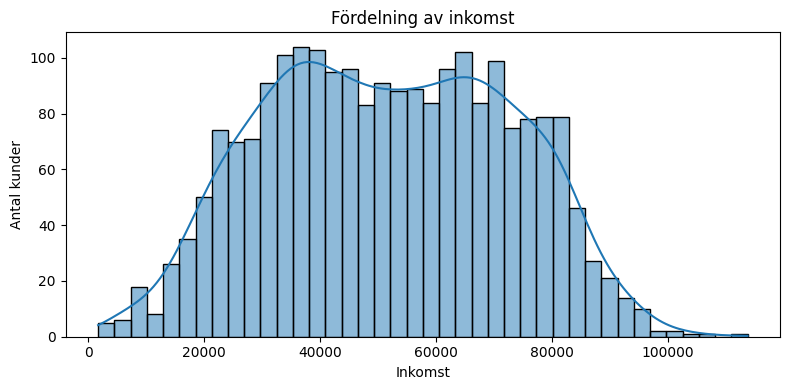

In [5]:
# Histogram över inkomst
plt.figure(figsize=(8, 4))
sns.histplot(df['Income'], bins=40, kde=True)
plt.title('Fördelning av inkomst')
plt.xlabel('Inkomst')
plt.ylabel('Antal kunder')
plt.tight_layout()
plt.show()

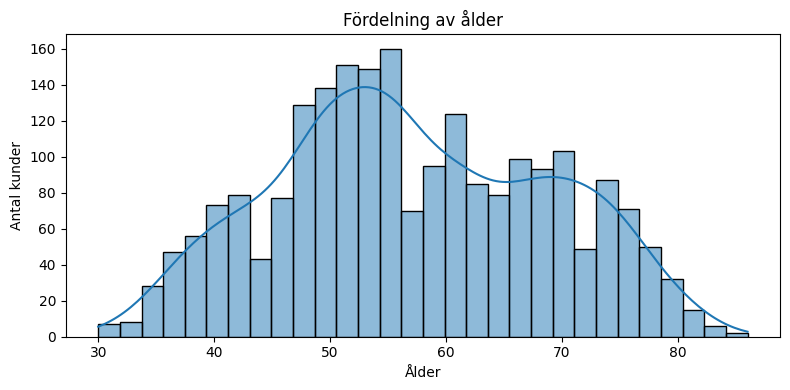

In [6]:
# Histogram över ålder
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Fördelning av ålder')
plt.xlabel('Ålder')
plt.ylabel('Antal kunder')
plt.tight_layout()
plt.show()

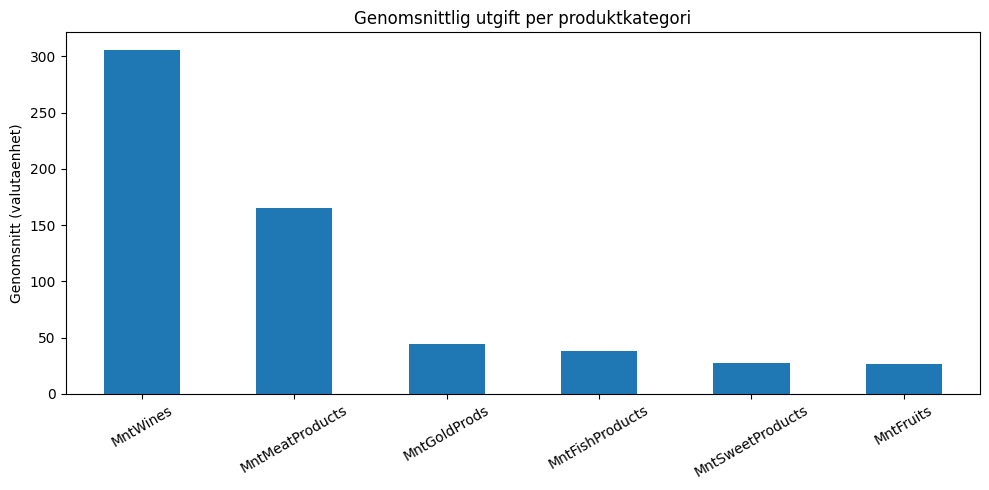

In [7]:
# Jämförelse av utgifter per produktkategori
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

plt.figure(figsize=(10, 5))
df[spend_cols].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Genomsnittlig utgift per produktkategori')
plt.ylabel('Genomsnitt (valutaenhet)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 2.4 Köpkanaler

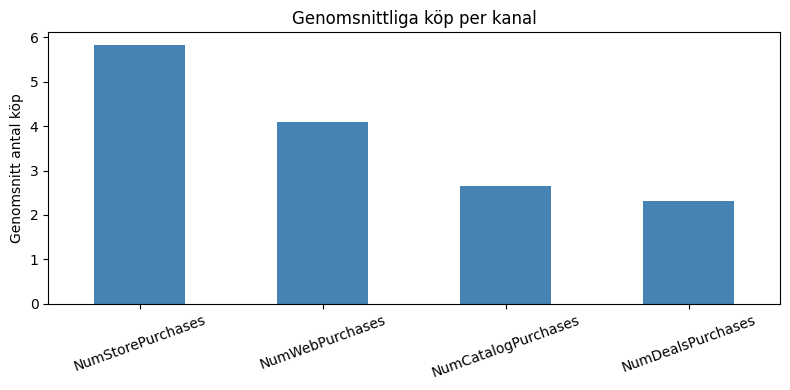

In [8]:
# Jämförelse av genomsnittliga köp per kanal
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']

plt.figure(figsize=(8, 4))
df[channel_cols].mean().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Genomsnittliga köp per kanal')
plt.ylabel('Genomsnitt antal köp')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

---
## 2.5 Relationer mellan variabler

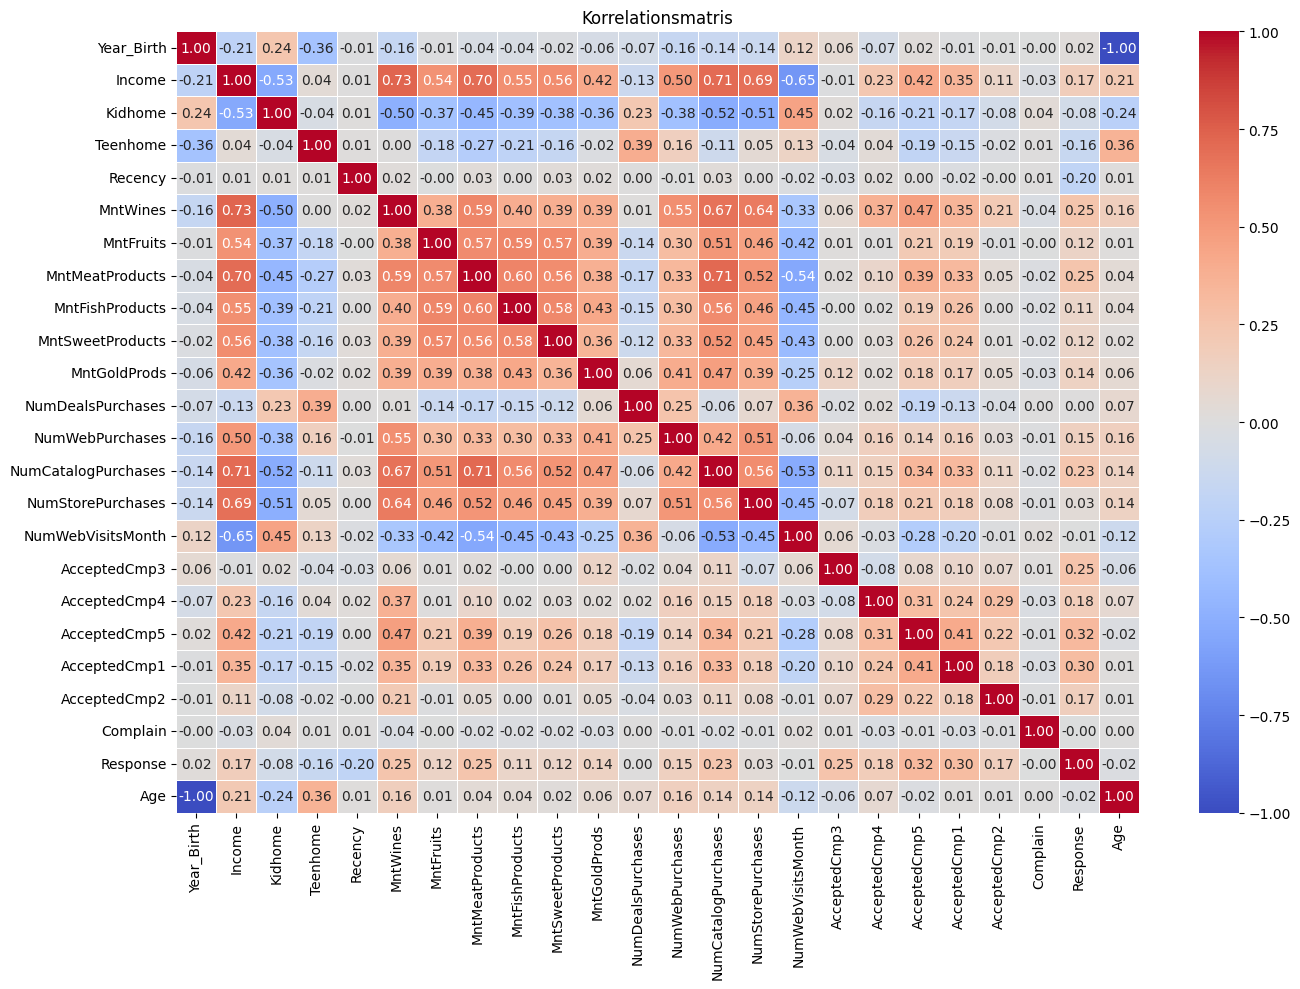

In [9]:
# Korrelationsmatris för numeriska variabler
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Korrelationsmatris')
plt.tight_layout()
plt.show()

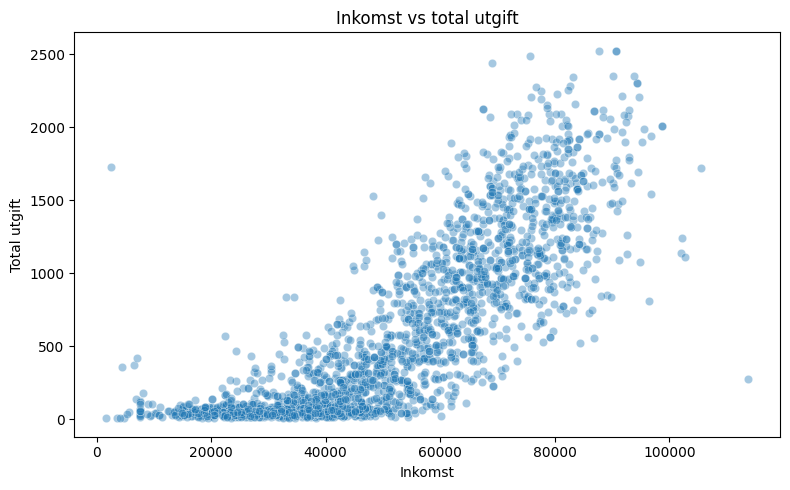

In [10]:
# Inkomst vs total utgift — finns det ett samband?
df['TotalSpend'] = df[spend_cols].sum(axis=1)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Income', y='TotalSpend', alpha=0.4)
plt.title('Inkomst vs total utgift')
plt.xlabel('Inkomst')
plt.ylabel('Total utgift')
plt.tight_layout()
plt.show()

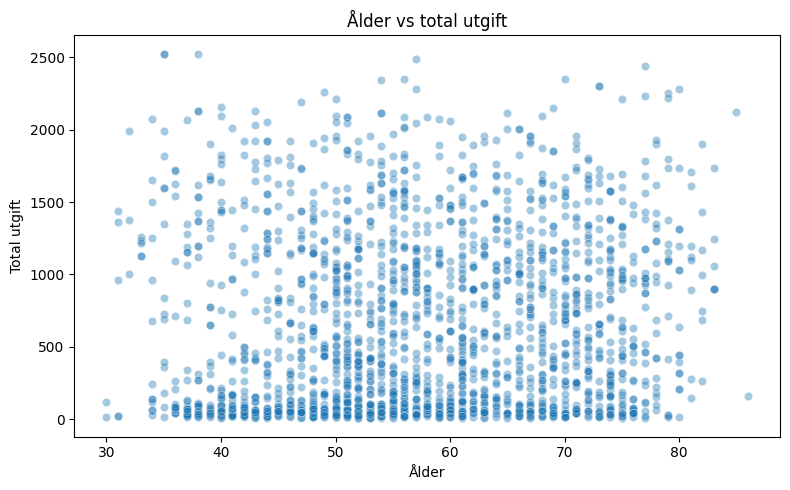

In [11]:
# Ålder vs total utgift
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='TotalSpend', alpha=0.4)
plt.title('Ålder vs total utgift')
plt.xlabel('Ålder')
plt.ylabel('Total utgift')
plt.tight_layout()
plt.show()

---
## 2.6 Skillnader mellan grupper

In [12]:
# Genomsnittlig inkomst och utgift per utbildningsnivå
df.groupby('Education')[['Income', 'TotalSpend']].mean().sort_values('Income', ascending=False)

,Income,TotalSpend
Education,,
PhD,55220.581933,672.722689
Master,52629.579670,611.280220
Graduation,51984.008086,621.746631
2n Cycle,47625.333333,499.489899
Basic,20306.259259,81.796296


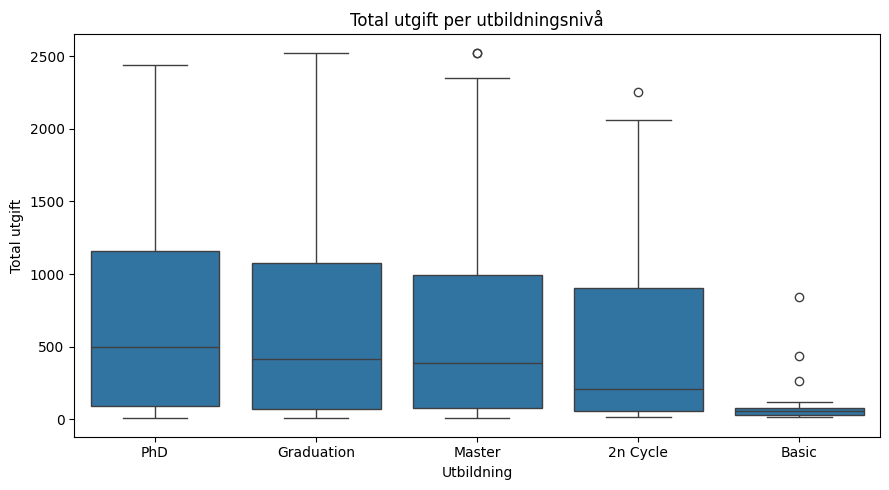

In [13]:
# Boxplot — total utgift per utbildningsnivå
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Education', y='TotalSpend', order=df.groupby('Education')['TotalSpend'].median().sort_values(ascending=False).index)
plt.title('Total utgift per utbildningsnivå')
plt.xlabel('Utbildning')
plt.ylabel('Total utgift')
plt.tight_layout()
plt.show()

In [14]:
# Köpbeteende — kunder med barn vs utan barn
df['HasChildren'] = ((df['Kidhome'] + df['Teenhome']) > 0).astype(int)

df.groupby('HasChildren')[['Income', 'TotalSpend', 'MntWines', 'MntMeatProducts']].mean()

,Income,TotalSpend,MntWines,MntMeatProducts
HasChildren,,,,
0,65094.417197,1105.585987,490.662420,367.589172
1,46257.086240,408.201649,232.693088,84.760304


---
## 2.7 Kampanjrespons

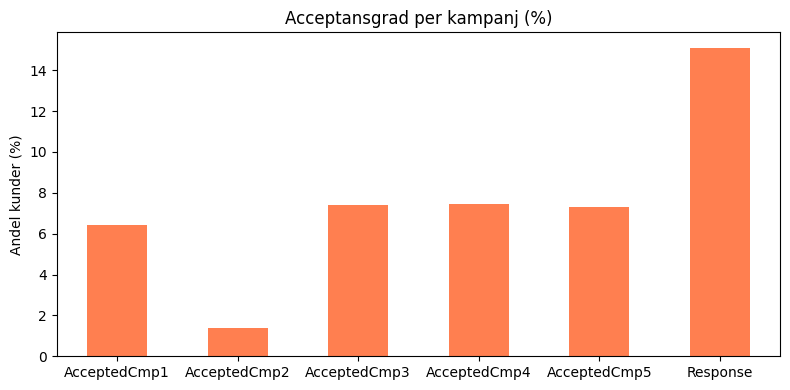

In [15]:
# Hur stor andel av kunderna accepterade varje kampanj?
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

acceptance_rate = df[campaign_cols].mean() * 100

plt.figure(figsize=(8, 4))
acceptance_rate.plot(kind='bar', color='coral')
plt.title('Acceptansgrad per kampanj (%)')
plt.ylabel('Andel kunder (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# Skiljer sig inkomst och utgift mellan de som svarade på senaste kampanjen och de som inte gjorde det?
df.groupby('Response')[['Income', 'TotalSpend', 'Age']].mean()

,Income,TotalSpend,Age
Response,,,
0,50094.496261,539.432158,57.200855
1,60209.675676,985.660661,56.504505


---
## 2.8 Sammanfattning av fynd

In [17]:
# Snabb överblick — medelvärden för hela kundbasen
summary = {
    'Antal kunder': len(df),
    'Genomsnittlig ålder': df['Age'].mean().round(1),
    'Genomsnittlig inkomst': df['Income'].mean().round(0),
    'Genomsnittlig total utgift': df['TotalSpend'].mean().round(0),
    'Andel med barn (%)': (df['HasChildren'].mean() * 100).round(1)
}

for k, v in summary.items():
    print(f'{k}: {v}')

Antal kunder: 2205
Genomsnittlig ålder: 57.1
Genomsnittlig inkomst: 51622.0
Genomsnittlig total utgift: 607.0
Andel med barn (%): 71.5
